# AnalyticGAN -- Notebook 5: Evaluation

Evaluates synthetic data quality across four dimensions:

**Statistical Fidelity** - **Correlation Structure** - **ML Efficacy** - **Privacy**


In [28]:
import os, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from scipy.spatial.distance import jensenshannon
from scipy.spatial import cKDTree

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import LabelEncoder

import kagglehub

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [29]:
_here    = os.path.abspath(os.getcwd())
BASE     = _here if os.path.basename(_here) != "notebooks" else os.path.dirname(_here)
CKPT_DIR = os.path.join(BASE, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

_kaggle_root = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
from pathlib import Path as _Path
_cands = list(_Path(_kaggle_root).rglob("creditcard.csv"))
if not _cands:
    raise FileNotFoundError("creditcard.csv not found under kagglehub path")
RAW_CSV = str(_cands[0])

print(f"CKPT_DIR : {CKPT_DIR}")
print(f"RAW_CSV  : {RAW_CSV}")


CKPT_DIR : c:\Users\Owner\Desktop\EAI-6020-Final Project\analyticgan\checkpoints
RAW_CSV  : C:\Users\Owner\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


## Class Definitions (self-contained)


In [30]:
class VGMEncoder:
    def __init__(self, n_components=10, eps=0.005):
        self.n_components = n_components
        self.eps          = eps
        self.bgm = BayesianGaussianMixture(
            n_components=n_components,
            weight_concentration_prior_type="dirichlet_process",
            weight_concentration_prior=0.001,
            max_iter=100, random_state=42, n_init=1)
        self.valid_components = None
        self.n_valid          = None

    def fit(self, data):
        data = np.asarray(data).reshape(-1, 1)
        self.bgm.fit(data)
        self.valid_components = np.where(self.bgm.weights_ > self.eps)[0]
        self.n_valid = len(self.valid_components)
        return self

    def transform(self, data):
        data  = np.asarray(data).reshape(-1, 1)
        means = self.bgm.means_[self.valid_components].flatten()
        stds  = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()
        probs = self.bgm.predict_proba(data)[:, self.valid_components]
        mode_idx = []
        for p in probs:
            s      = p.sum()
            p_norm = (p / s).astype(np.float64) if (s > 0 and np.isfinite(s)) else np.ones(self.n_valid) / self.n_valid
            mode_idx.append(np.random.choice(self.n_valid, p=p_norm))
        mode_idx   = np.array(mode_idx)
        normalized = np.clip(
            (data.flatten() - means[mode_idx]) / (4 * stds[mode_idx] + 1e-8),
            -0.99, 0.99)
        one_hot = np.zeros((len(data), self.n_valid), dtype=np.float32)
        one_hot[np.arange(len(data)), mode_idx] = 1
        return np.column_stack([normalized, one_hot]).astype(np.float32)

    def inverse_transform(self, encoded):
        encoded  = np.asarray(encoded)
        means    = self.bgm.means_[self.valid_components].flatten()
        stds     = np.sqrt(self.bgm.covariances_[self.valid_components]).flatten()
        mode_idx = np.argmax(encoded[:, 1:], axis=1)
        return encoded[:, 0] * 4 * stds[mode_idx] + means[mode_idx]


class TabularPreprocessor:
    def __init__(self, max_gmm_components=10, eps=0.005):
        self.max_gmm_components = max_gmm_components
        self.eps             = eps
        self.continuous_cols = []
        self.categorical_cols= []
        self.target_col      = None
        self.vgm_encoders    = {}
        self.label_encoders  = {}
        self.cat_dims        = {}
        self.output_info     = []
        self.output_dim      = 0

    def fit(self, df, continuous_cols, categorical_cols, target_col):
        self.continuous_cols  = continuous_cols
        self.categorical_cols = categorical_cols
        self.target_col       = target_col
        self.output_info = []; self.output_dim = 0
        for col in continuous_cols:
            enc = VGMEncoder(self.max_gmm_components, self.eps)
            enc.fit(df[col].values)
            self.vgm_encoders[col] = enc
            self.output_info.append(("continuous", col, enc.n_valid))
            self.output_dim += 1 + enc.n_valid
        for col in categorical_cols:
            le = LabelEncoder(); le.fit(df[col].astype(str))
            self.label_encoders[col] = le
            n_cat = len(le.classes_)
            self.cat_dims[col] = n_cat
            self.output_info.append(("categorical", col, n_cat))
            self.output_dim += n_cat
        return self

    def transform(self, df):
        parts = []
        for kind, col, _ in self.output_info:
            if kind == "continuous":
                parts.append(self.vgm_encoders[col].transform(df[col].values))
            else:
                lbls  = self.label_encoders[col].transform(df[col].astype(str))
                n_cat = self.cat_dims[col]
                oh    = np.zeros((len(df), n_cat), dtype=np.float32)
                oh[np.arange(len(df)), lbls] = 1
                parts.append(oh)
        data_arr = np.concatenate(parts, axis=1)
        n_cls = df[self.target_col].nunique()
        tgt   = df[self.target_col].values.astype(int)
        cond  = np.zeros((len(df), n_cls), dtype=np.float32)
        cond[np.arange(len(df)), tgt] = 1
        return torch.tensor(data_arr, dtype=torch.float32), cond

    def inverse_transform(self, tensor):
        data, result, idx = tensor.detach().cpu().numpy(), {}, 0
        for kind, col, size in self.output_info:
            if kind == "continuous":
                w = 1 + self.vgm_encoders[col].n_valid
                result[col] = self.vgm_encoders[col].inverse_transform(data[:, idx:idx+w])
                idx += w
            else:
                n_cat = self.cat_dims[col]
                result[col] = self.label_encoders[col].inverse_transform(
                    np.argmax(data[:, idx:idx+n_cat], axis=1))
                idx += n_cat
        return pd.DataFrame(result)

    @staticmethod
    def load(path):
        with open(path, "rb") as f: return pickle.load(f)


class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim))
    def forward(self, x):
        return F.relu(x + self.block(x))


class SelfAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        ad = max(dim // 8, 1)
        self.query    = nn.Linear(dim, ad, bias=False)
        self.key      = nn.Linear(dim, ad, bias=False)
        self.value    = nn.Linear(dim, ad, bias=False)
        self.out_proj = nn.Linear(ad, dim, bias=False)
        self.scale    = ad ** -0.5
    def forward(self, x):
        Q, K, V = self.query(x), self.key(x), self.value(x)
        attn    = F.softmax(Q @ K.T * self.scale, dim=-1)
        return x + self.out_proj(attn @ V)


class DiscResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Linear(dim, dim)), nn.LeakyReLU(0.2),
            spectral_norm(nn.Linear(dim, dim)))
    def forward(self, x):
        return F.leaky_relu(x + self.block(x), 0.2)


class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim, output_dim,
                 output_info, hidden_dims=None):
        super().__init__()
        if hidden_dims is None: hidden_dims = [256, 256]
        self.output_info = output_info
        self.input_layer = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]), nn.ReLU())
        self.res_blocks   = nn.ModuleList([ResidualBlock(d) for d in hidden_dims])
        self.self_attn    = SelfAttention(hidden_dims[-1])
        self.output_layer = nn.Linear(hidden_dims[-1], output_dim)

    def forward(self, z, cond):
        x = self.input_layer(torch.cat([z, cond], dim=1))
        for b in self.res_blocks: x = b(x)
        x = self.self_attn(x)
        return self._apply_activations(self.output_layer(x))

    def _apply_activations(self, x):
        out, idx = [], 0
        for kind, _, size in self.output_info:
            if kind == "continuous":
                out.append(torch.tanh(x[:, idx:idx+1]))
                out.append(F.softmax(x[:, idx+1:idx+1+size], dim=1))
                idx += 1 + size
            else:
                out.append(F.softmax(x[:, idx:idx+size], dim=1))
                idx += size
        return torch.cat(out, dim=1)


class ConditionalSampler:
    def __init__(self, preprocessor, cond_vec, device, fraud_pct=0.20):
        self.prep      = preprocessor
        self.device    = device
        self.n_classes = cond_vec.shape[1]
        if fraud_pct is not None and self.n_classes == 2:
            weights = np.array([1.0 - fraud_pct, fraud_pct])
        else:
            counts = cond_vec.sum(axis=0).astype(np.float64)
            inv     = 1.0 / (counts + 1e-8)
            weights = inv / inv.sum()
        self.weights = torch.tensor(weights.astype(np.float32), device=device)
        labels         = np.argmax(cond_vec, axis=1)
        self.class_idx = {
            c: torch.tensor(np.where(labels == c)[0], device=device)
            for c in range(self.n_classes)}
        self.eye = torch.eye(self.n_classes, device=device)

    def sample_cond(self, n):
        cls = torch.multinomial(
            self.weights.unsqueeze(0).expand(n, -1),
            num_samples=1).squeeze(1)
        return self.eye[cls]


print("All classes loaded.")


All classes loaded.


## Load Data & Artifacts


In [31]:
prep     = TabularPreprocessor.load(os.path.join(CKPT_DIR, "preprocessor.pkl"))
cond_vec = np.load(os.path.join(CKPT_DIR, "cond_vec.npy"))

with open(os.path.join(CKPT_DIR, "training_history.pkl"), "rb") as f:
    history = pickle.load(f)

df_real = pd.read_csv(RAW_CSV)
print(f"Real data     : {df_real.shape}")
print(f"Epochs logged : {len(history['d_loss'])}")


Real data     : (284807, 31)
Epochs logged : 100


## Generate 10,000 Synthetic Rows (fraud oversampled to 20%)


In [32]:
LAT_DIM     = 128
HIDDEN_DIMS = [256, 256]
N_SYNTH     = 10_000

G = Generator(
    latent_dim  = LAT_DIM,
    cond_dim    = cond_vec.shape[1],
    output_dim  = prep.output_dim,
    output_info = prep.output_info,
    hidden_dims = HIDDEN_DIMS,
).to(device)

_sd = torch.load(os.path.join(CKPT_DIR, "generator_final.pt"),
                 map_location=device)
_sd = {k.replace("_orig_mod.", ""): v for k, v in _sd.items()}
G.load_state_dict(_sd)
G.eval()

sampler = ConditionalSampler(prep, cond_vec, device, fraud_pct=0.20)

with torch.no_grad():
    z   = torch.randn(N_SYNTH, LAT_DIM, device=device)
    c   = sampler.sample_cond(N_SYNTH)
    out = G(z, c)

df_synth          = prep.inverse_transform(out.cpu())
df_synth["Class"] = np.argmax(c.cpu().numpy(), axis=1)

print(f"Synthetic data : {df_synth.shape}")
print(df_synth["Class"].value_counts().to_string())


Synthetic data : (10000, 31)
Class
0    7981
1    2019


## Section A -- Statistical Fidelity


In [33]:
FEAT_COLS = [f"V{i}" for i in range(1, 29)] + ["Amount"]

rows = []
for col in FEAT_COLS:
    r = df_real[col]; s = df_synth[col]
    rows.append({
        "Column"   : col,
        "Real mean": f"{r.mean():.4f}",
        "Syn mean" : f"{s.mean():.4f}",
        "Real std" : f"{r.std():.4f}",
        "Syn std"  : f"{s.std():.4f}",
        "Real min" : f"{r.min():.4f}",
        "Syn min"  : f"{s.min():.4f}",
        "Real max" : f"{r.max():.4f}",
        "Syn max"  : f"{s.max():.4f}",
    })

df_stats = pd.DataFrame(rows)
print("=== Per-column Statistics: Real vs Synthetic ===")
print(df_stats.to_string(index=False))
df_stats.to_csv(os.path.join(CKPT_DIR, "stats_comparison.csv"), index=False)


=== Per-column Statistics: Real vs Synthetic ===
Column Real mean Syn mean Real std  Syn std  Real min   Syn min   Real max   Syn max
    V1    0.0000   0.2205   1.9587   2.3395  -56.4075  -17.7265     2.4549    2.6709
    V2    0.0000  -0.4987   1.6513   2.7855  -72.7157  -12.2134    22.0577   12.1536
    V3   -0.0000   0.5805   1.5163   2.2905  -48.3256   -8.8428     9.3826    4.3178
    V4    0.0000   0.2014   1.4159   2.1129   -5.6832   -6.0074    16.8753    6.2677
    V5    0.0000   0.0138   1.3802   2.1974 -113.7433  -16.0237    34.8017   14.5953
    V6    0.0000  -0.5080   1.3323   2.4076  -26.1605  -10.4351    73.3016   11.9775
    V7   -0.0000   0.0744   1.2371   1.6939  -43.5572  -14.3238   120.5895   13.7833
    V8    0.0000   0.2310   1.1944   2.3793  -73.2167  -12.3730    20.0072   12.6838
    V9   -0.0000  -0.0735   1.0986   1.4624  -13.4341   -3.8536    15.5950   14.4871
   V10    0.0000  -0.0172   1.0888   1.6730  -24.5883  -10.5321    23.7451   17.6659
   V11    0.0000

In [34]:
ks_rows = []
for col in FEAT_COLS:
    stat, p = stats.ks_2samp(df_real[col].values, df_synth[col].values)
    ks_rows.append({"Column": col, "KS stat": round(stat, 4),
                    "p-value": round(p, 4),
                    "Pass (a=0.05)": "PASS" if p > 0.05 else "FAIL"})

df_ks = pd.DataFrame(ks_rows)
passed = (df_ks["Pass (a=0.05)"] == "PASS").sum()
print(f"\n=== KS Test Results ({passed}/{len(FEAT_COLS)} columns pass) ===")
print(df_ks.to_string(index=False))



=== KS Test Results (0/29 columns pass) ===
Column  KS stat  p-value Pass (a=0.05)
    V1   0.2777      0.0          FAIL
    V2   0.3535      0.0          FAIL
    V3   0.2496      0.0          FAIL
    V4   0.2297      0.0          FAIL
    V5   0.2936      0.0          FAIL
    V6   0.3584      0.0          FAIL
    V7   0.3043      0.0          FAIL
    V8   0.4004      0.0          FAIL
    V9   0.1588      0.0          FAIL
   V10   0.2486      0.0          FAIL
   V11   0.1726      0.0          FAIL
   V12   0.2540      0.0          FAIL
   V13   0.2019      0.0          FAIL
   V14   0.2887      0.0          FAIL
   V15   0.1797      0.0          FAIL
   V16   0.2605      0.0          FAIL
   V17   0.3099      0.0          FAIL
   V18   0.2382      0.0          FAIL
   V19   0.1568      0.0          FAIL
   V20   0.4416      0.0          FAIL
   V21   0.4013      0.0          FAIL
   V22   0.2532      0.0          FAIL
   V23   0.4536      0.0          FAIL
   V24   0.2128    

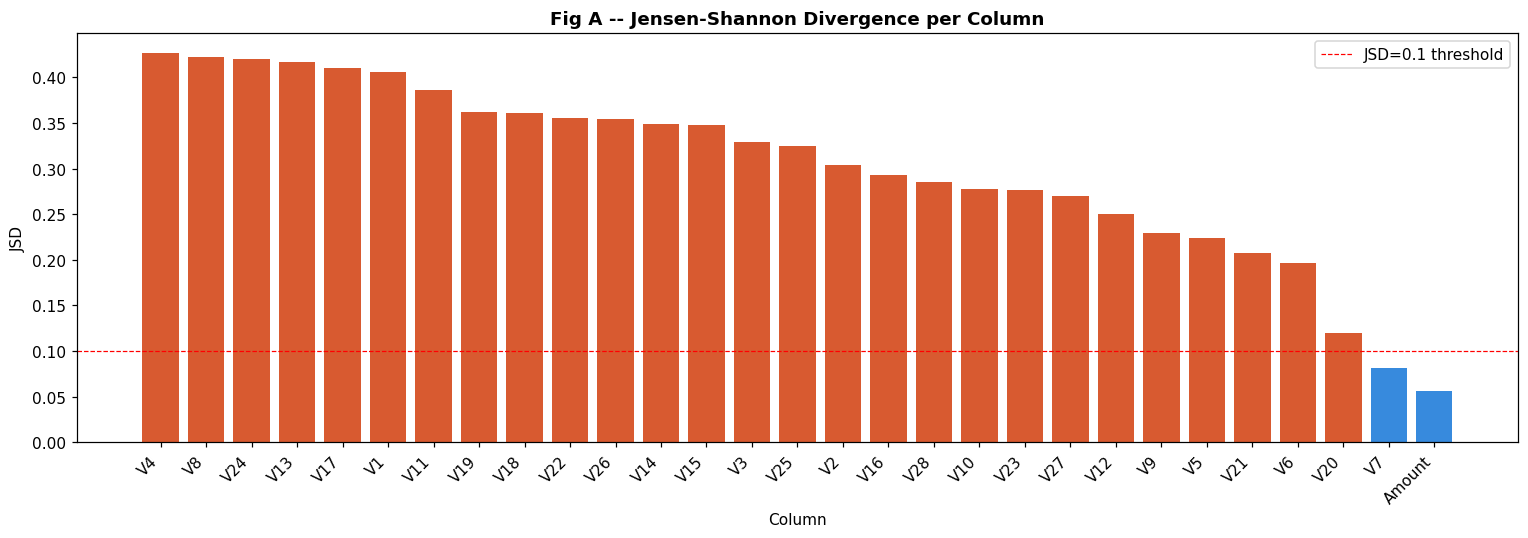

Mean JSD : 0.3015  |  Max JSD : 0.4272


In [35]:
def col_jsd(real_col, synth_col, bins=50):
    lo = min(real_col.min(), synth_col.min())
    hi = max(real_col.max(), synth_col.max())
    edges   = np.linspace(lo, hi, bins + 1)
    p, _    = np.histogram(real_col,  bins=edges, density=True)
    q, _    = np.histogram(synth_col, bins=edges, density=True)
    p = p + 1e-10; q = q + 1e-10
    return jensenshannon(p / p.sum(), q / q.sum())

jsd_vals = {col: col_jsd(df_real[col].values, df_synth[col].values)
            for col in FEAT_COLS}
jsd_ser  = pd.Series(jsd_vals).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors  = ["#D85A30" if v > 0.1 else "#378ADD" for v in jsd_ser.values]
ax.bar(jsd_ser.index, jsd_ser.values, color=colors)
ax.axhline(0.1, color="red", linestyle="--", linewidth=0.8, label="JSD=0.1 threshold")
ax.set_title("Fig A -- Jensen-Shannon Divergence per Column", fontsize=12, fontweight="bold")
ax.set_xlabel("Column"); ax.set_ylabel("JSD")
ax.legend(); plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figA_jsd.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"Mean JSD : {jsd_ser.mean():.4f}  |  Max JSD : {jsd_ser.max():.4f}")


## Section B -- Correlation Structure


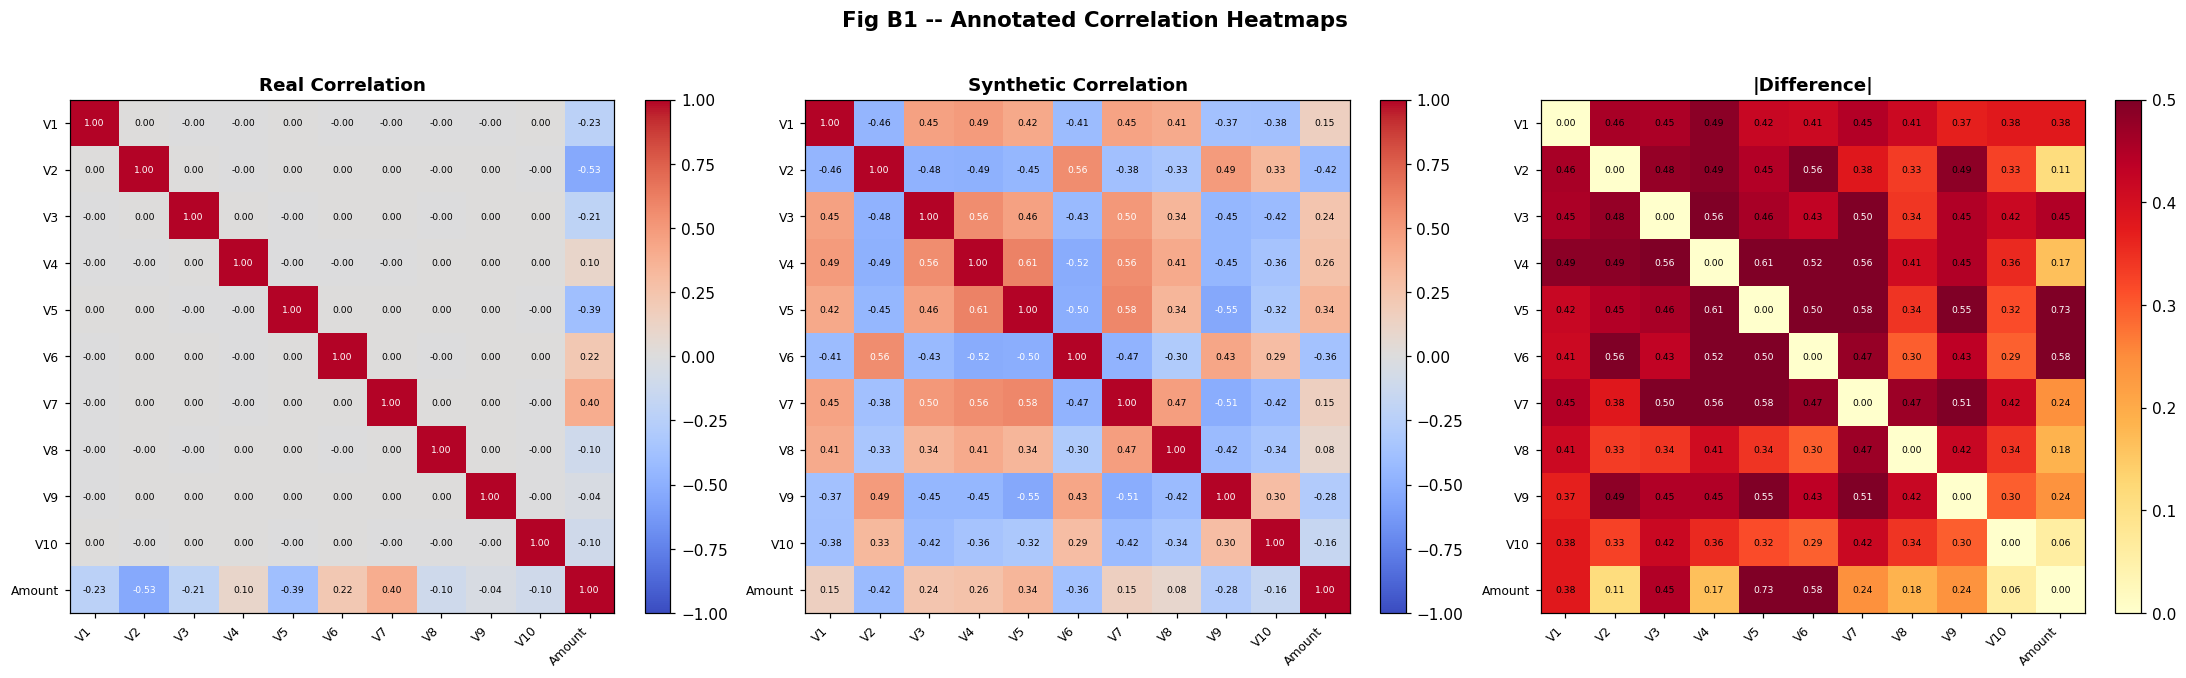

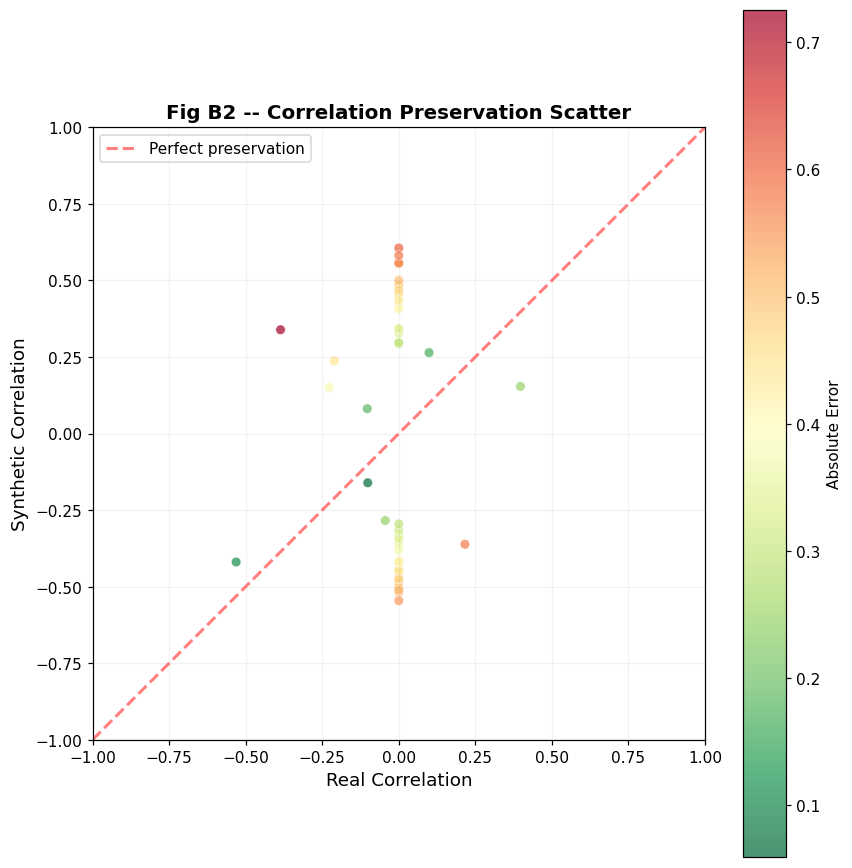

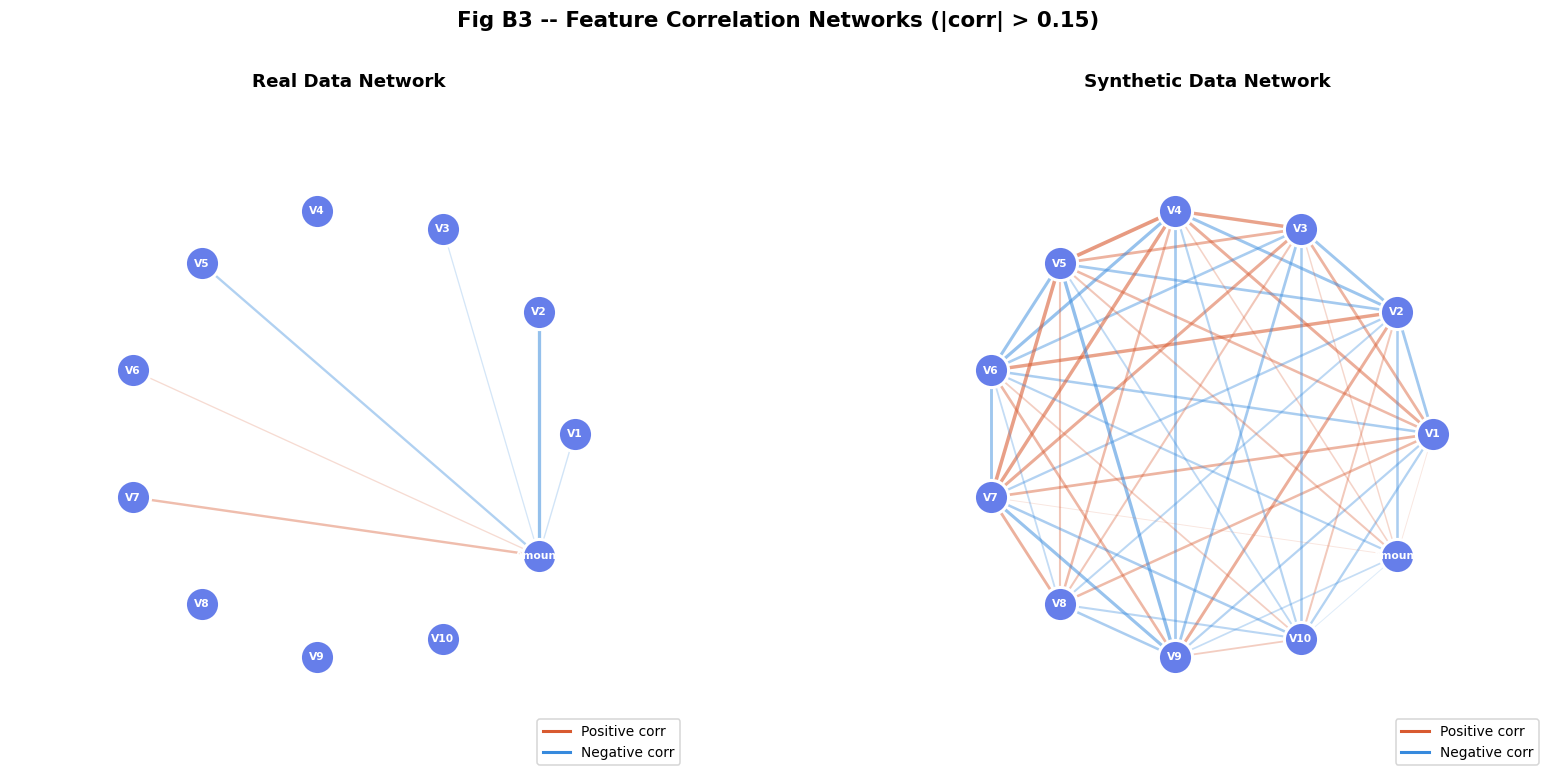

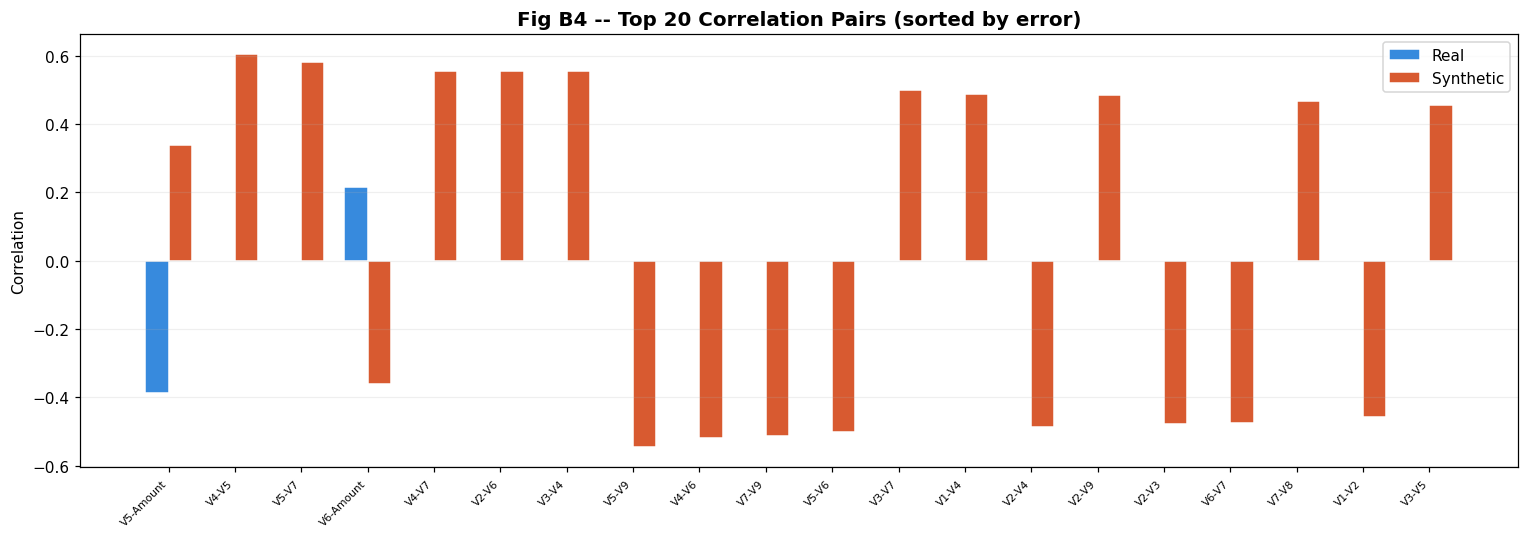

Mean absolute correlation diff : 0.4136
Max correlation error           : 0.7253
Pairs with error < 0.05         : 0/55


In [36]:
# ============================================================
# CELL 15 — Correlation Analysis (4 plots)
# ============================================================
CORR_COLS = [f"V{i}" for i in range(1, 11)] + ["Amount"]

corr_real  = df_real[CORR_COLS].corr()
corr_synth = df_synth[CORR_COLS].corr()
corr_diff  = (corr_real - corr_synth).abs()
corr_diff_vals = corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)]

# ---- Plot 1: Annotated Heatmaps (Real vs Synthetic vs Diff) ----
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, mat, title, cmap in zip(
    axes, [corr_real, corr_synth, corr_diff],
    ["Real Correlation", "Synthetic Correlation", "|Difference|"],
    ["coolwarm", "coolwarm", "YlOrRd"]):
    vmin = -1 if cmap == "coolwarm" else 0
    vmax = 1 if cmap == "coolwarm" else 0.5
    im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    for i in range(len(CORR_COLS)):
        for j in range(len(CORR_COLS)):
            val = mat.values[i, j]
            color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=color)
    ax.set_xticks(range(len(CORR_COLS)))
    ax.set_xticklabels(CORR_COLS, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(CORR_COLS)))
    ax.set_yticklabels(CORR_COLS, fontsize=8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Fig B1 -- Annotated Correlation Heatmaps", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figB_correlation.png"), dpi=120, bbox_inches="tight")
plt.show()

# ---- Plot 2: Scatter — Real vs Synthetic Correlations ----
real_flat = corr_real.values[np.triu_indices_from(corr_real.values, k=1)]
syn_flat  = corr_synth.values[np.triu_indices_from(corr_synth.values, k=1)]
diff_flat = np.abs(real_flat - syn_flat)

fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(real_flat, syn_flat, s=40, c=diff_flat, cmap="RdYlGn_r",
                alpha=0.7, edgecolors="white", linewidth=0.5)
ax.plot([-1, 1], [-1, 1], color="red", ls="--", lw=2, alpha=0.5, label="Perfect preservation")
ax.set_xlabel("Real Correlation", fontsize=12)
ax.set_ylabel("Synthetic Correlation", fontsize=12)
ax.set_title("Fig B2 -- Correlation Preservation Scatter", fontweight="bold", fontsize=13)
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect("equal")
ax.grid(alpha=0.15); ax.legend(fontsize=10)
plt.colorbar(sc, ax=ax, label="Absolute Error")
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figB2_corr_scatter.png"), dpi=120, bbox_inches="tight")
plt.show()

# ---- Plot 3: Network Graph — Feature Relationships ----
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
n = len(CORR_COLS)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
x_pos = np.cos(angles) * 3
y_pos = np.sin(angles) * 3

for ax, mat, title in zip(axes, [corr_real, corr_synth], ["Real Data Network", "Synthetic Data Network"]):
    for i in range(n):
        for j in range(i + 1, n):
            val = mat.values[i, j]
            if abs(val) > 0.15:
                color = "#D85A30" if val > 0 else "#378ADD"
                alpha = min(abs(val), 0.8)
                width = abs(val) * 4
                ax.plot([x_pos[i], x_pos[j]], [y_pos[i], y_pos[j]],
                        color=color, alpha=alpha, linewidth=width)
    ax.scatter(x_pos, y_pos, s=500, c="#667eea", edgecolors="white", linewidth=2, zorder=5)
    for i, name in enumerate(CORR_COLS):
        ax.annotate(name, (x_pos[i], y_pos[i]), ha="center", va="center",
                    fontsize=7, fontweight="bold", color="white", zorder=6)
    ax.set_title(title, fontweight="bold", fontsize=12)
    ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
    ax.set_aspect("equal"); ax.axis("off")
    ax.plot([], [], color="#D85A30", linewidth=2, label="Positive corr")
    ax.plot([], [], color="#378ADD", linewidth=2, label="Negative corr")
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Fig B3 -- Feature Correlation Networks (|corr| > 0.15)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figB3_corr_network.png"), dpi=120, bbox_inches="tight")
plt.show()

# ---- Plot 4: Bar Chart — Per-pair Correlation Error ----
pairs = []
for i in range(n):
    for j in range(i + 1, n):
        pairs.append({
            "Pair": f"{CORR_COLS[i]}-{CORR_COLS[j]}",
            "Real": corr_real.values[i, j],
            "Synth": corr_synth.values[i, j],
            "Error": abs(corr_real.values[i, j] - corr_synth.values[i, j])
        })
df_pairs = pd.DataFrame(pairs).sort_values("Error", ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
top_n = min(20, len(df_pairs))
top = df_pairs.head(top_n)
x = np.arange(top_n)
w = 0.35
ax.bar(x - w/2, top["Real"].values, w, color="#378ADD", label="Real", edgecolor="white")
ax.bar(x + w/2, top["Synth"].values, w, color="#D85A30", label="Synthetic", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(top["Pair"].values, rotation=45, ha="right", fontsize=7)
ax.set_title("Fig B4 -- Top 20 Correlation Pairs (sorted by error)", fontweight="bold", fontsize=13)
ax.set_ylabel("Correlation"); ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figB4_corr_pairs.png"), dpi=120, bbox_inches="tight")
plt.show()

# Summary
print(f"Mean absolute correlation diff : {corr_diff_vals.mean():.4f}")
print(f"Max correlation error           : {corr_diff_vals.max():.4f}")
print(f"Pairs with error < 0.05         : {(corr_diff_vals < 0.05).sum()}/{len(corr_diff_vals)}")


## Section C -- ML Efficacy (TSTR vs TRTR)


In [37]:
FEATURES = [f"V{i}" for i in range(1, 29)] + ["Amount"]
TARGET   = "Class"

X_real = df_real[FEATURES].values
y_real = df_real[TARGET].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)

X_synth = df_synth[FEATURES].values
y_synth = df_synth[TARGET].values

def eval_rf(X_train, y_train, X_test, y_test, label):
    clf = RandomForestClassifier(n_estimators=200, random_state=42,
                                 n_jobs=-1, class_weight="balanced")
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    return {
        "Setup"    : label,
        "Accuracy" : round(accuracy_score(y_test, y_pred),  4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred,    zero_division=0), 4),
        "F1"       : round(f1_score(y_test, y_pred,        zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_proba), 4),
    }

print("Training TRTR (real -> real) ...")
trtr = eval_rf(X_tr, y_tr, X_te, y_te, "TRTR (baseline)")

print("Training TSTR (synthetic -> real) ...")
tstr = eval_rf(X_synth, y_synth, X_te, y_te, "TSTR (synthetic)")

df_mleff = pd.DataFrame([trtr, tstr])
print("\n=== ML Efficacy: TSTR vs TRTR ===")
print(df_mleff.to_string(index=False))
df_mleff.to_csv(os.path.join(CKPT_DIR, "ml_efficacy.csv"), index=False)


Training TRTR (real -> real) ...
Training TSTR (synthetic -> real) ...

=== ML Efficacy: TSTR vs TRTR ===
           Setup  Accuracy  Precision  Recall     F1  ROC-AUC
 TRTR (baseline)    0.9995      0.961  0.7551 0.8457   0.9572
TSTR (synthetic)    0.9983      0.000  0.0000 0.0000   0.4738


## Section D -- Privacy: Nearest-Neighbour Distance Ratio (NNDR)


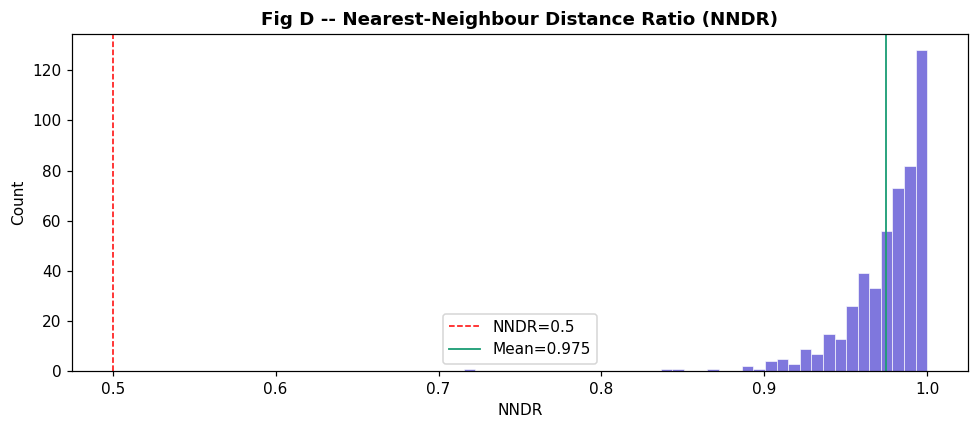

Mean NNDR : 0.9746  (Good privacy)


In [38]:
N_PRIV = 500
np.random.seed(42)

real_sample  = df_real[FEATURES].sample(N_PRIV, random_state=42).values.astype(np.float32)
synth_sample = df_synth[FEATURES].sample(N_PRIV, random_state=42).values.astype(np.float32)

mu  = real_sample.mean(axis=0)
std = real_sample.std(axis=0) + 1e-8
real_norm  = (real_sample - mu) / std
synth_norm = (synth_sample - mu) / std

tree  = cKDTree(real_norm)
dists, _ = tree.query(synth_norm, k=2)

nndr = dists[:, 0] / (dists[:, 1] + 1e-10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(nndr, bins=40, color="#7F77DD", edgecolor="white", linewidth=0.4)
ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="NNDR=0.5")
ax.axvline(nndr.mean(), color="#1D9E75", linestyle="-", linewidth=1.2,
           label=f"Mean={nndr.mean():.3f}")
ax.set_title("Fig D -- Nearest-Neighbour Distance Ratio (NNDR)", fontsize=12, fontweight="bold")
ax.set_xlabel("NNDR"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figD_nndr.png"), dpi=120, bbox_inches="tight")
plt.show()

privacy_status = "Good privacy" if nndr.mean() > 0.5 else "Privacy risk"
print(f"Mean NNDR : {nndr.mean():.4f}  ({privacy_status})")


## Section E -- Training Curve Recap


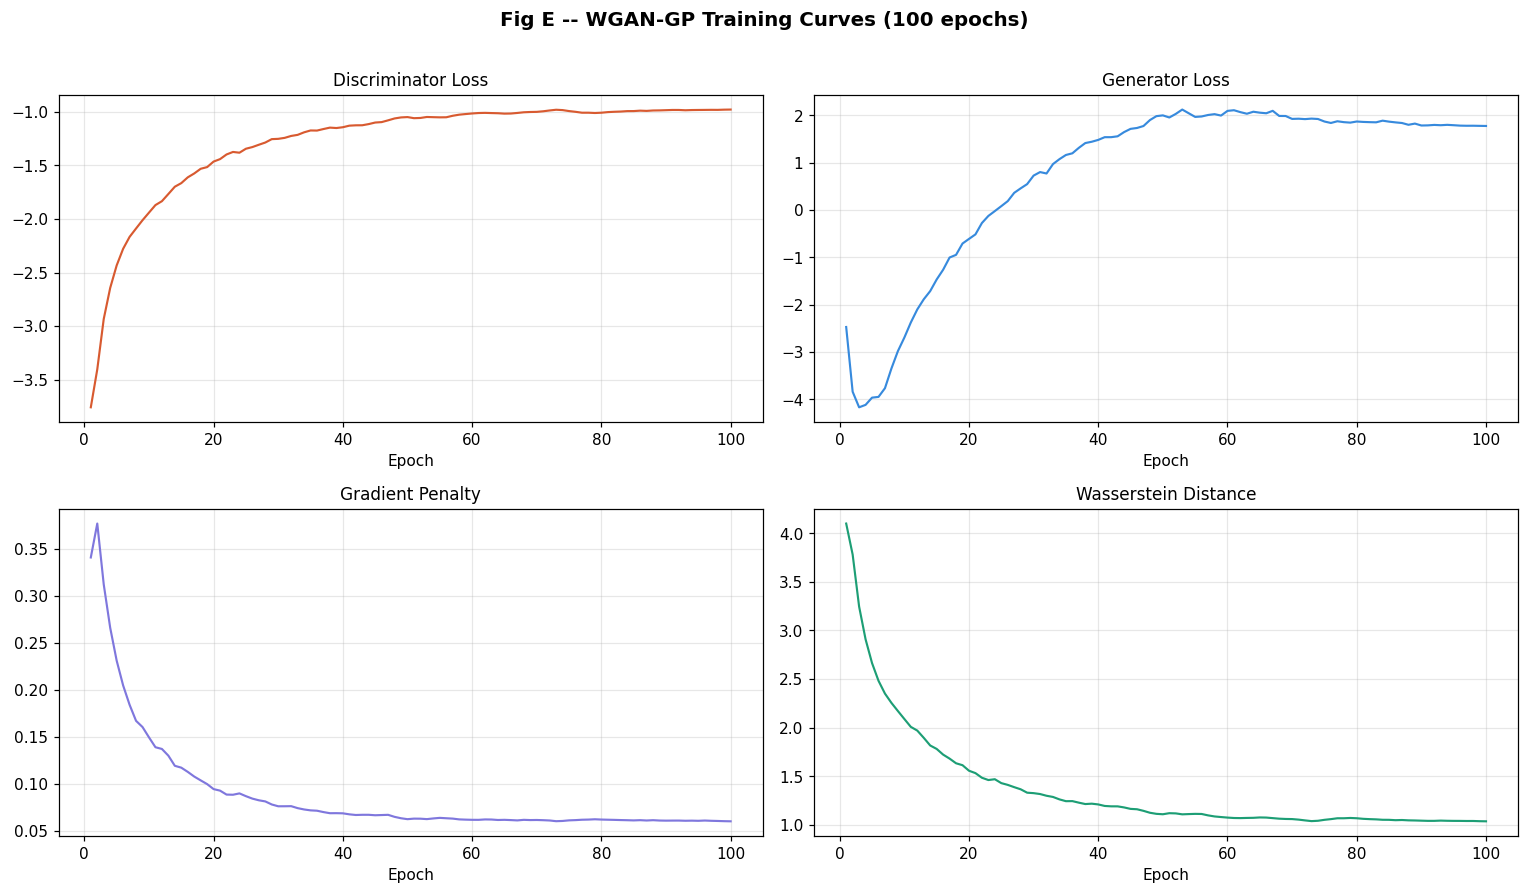

In [39]:
ep = range(1, len(history["d_loss"]) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes      = axes.flatten()

for ax, key, label, color in zip(
    axes,
    ["d_loss", "g_loss", "gp", "w_dist"],
    ["Discriminator Loss", "Generator Loss",
     "Gradient Penalty",  "Wasserstein Distance"],
    ["#D85A30", "#378ADD", "#7F77DD", "#1D9E75"],
):
    ax.plot(ep, history[key], color=color, linewidth=1.4)
    ax.set_title(label, fontsize=11); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)

plt.suptitle(f"Fig E -- WGAN-GP Training Curves ({len(history['d_loss'])} epochs)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "figE_training_recap.png"), dpi=120, bbox_inches="tight")
plt.show()


## Final Evaluation Summary


In [40]:
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)

print(f"\n[A] Statistical Fidelity")
print(f"    KS test pass rate  : {passed}/{len(FEAT_COLS)} columns")
print(f"    Mean JSD           : {jsd_ser.mean():.4f}  (lower = better)")
print(f"    Max JSD            : {jsd_ser.max():.4f}")

print(f"\n[B] Correlation Structure")
print(f"    Mean |corr diff|   : {corr_diff_vals.mean():.4f}  (lower = better)")

print(f"\n[C] ML Efficacy")
for _, row in df_mleff.iterrows():
    print(f"    {row['Setup']:<25} "
          f"F1={row['F1']:.4f}  ROC-AUC={row['ROC-AUC']:.4f}")

print(f"\n[D] Privacy (NNDR)")
print(f"    Mean NNDR          : {nndr.mean():.4f}  ({privacy_status})")

print(f"\n[E] Training")
print(f"    Epochs             : {len(history['d_loss'])}")
print(f"    Final W-distance   : {history['w_dist'][-1]:.4f}")
print(f"    Best  W-distance   : {min(history['w_dist'], key=abs):.4f}")

print("\n" + "=" * 60)
print("Saved files:")
for f in ["stats_comparison.csv", "ml_efficacy.csv",
          "figA_jsd.png", "figB_correlation.png",
          "figD_nndr.png", "figE_training_recap.png"]:
    p = os.path.join(CKPT_DIR, f)
    status = "[ok]" if os.path.isfile(p) else "[MISSING]"
    print(f"  {status} checkpoints/{f}")
print("=" * 60)
print("\nNotebook 5 complete. Proceed to Notebook 6.")


EVALUATION SUMMARY

[A] Statistical Fidelity
    KS test pass rate  : 0/29 columns
    Mean JSD           : 0.3015  (lower = better)
    Max JSD            : 0.4272

[B] Correlation Structure
    Mean |corr diff|   : 0.4136  (lower = better)

[C] ML Efficacy
    TRTR (baseline)           F1=0.8457  ROC-AUC=0.9572
    TSTR (synthetic)          F1=0.0000  ROC-AUC=0.4738

[D] Privacy (NNDR)
    Mean NNDR          : 0.9746  (Good privacy)

[E] Training
    Epochs             : 100
    Final W-distance   : 1.0379
    Best  W-distance   : 1.0379

Saved files:
  [ok] checkpoints/stats_comparison.csv
  [ok] checkpoints/ml_efficacy.csv
  [ok] checkpoints/figA_jsd.png
  [ok] checkpoints/figB_correlation.png
  [ok] checkpoints/figD_nndr.png
  [ok] checkpoints/figE_training_recap.png

Notebook 5 complete. Proceed to Notebook 6.
